# 프로젝트 : 인물 모드(아웃포커싱) 사진 만들기

오늘 배운 `DeepLabV3` 의 semantic segmentation 으로 피사체 마스크를 따서 인물 모드 사진을 만들어봤다.
핸드폰 인물 모드처럼 **배경만 흐리게(아웃포커싱)** 하거나, 배경을 **다른 사진으로 통째로 바꾸는(크로마키)** 것까지 해봤다.

만들어 놓고 결과를 자세히 보니까 마스크가 군데군데 틀려서 사진이 어색했다. (특히 고양이가 사막 하늘에 둥둥 떠버렸다…)
그래서 **어디서 왜 틀리는지** 찾아보고, 어떻게 보완하면 좋을지까지 정리했다.

### 오늘 한 것
- DeepLabV3 로 피사체 마스크 만들기
- 마스크로 배경 블러(아웃포커싱) → 동물 / 인물
- 마스크로 배경 교체(크로마키) → 고양이를 사막에
- 마스크가 틀리는 부분 찾아서 분석
- semantic segmentation 의 한계랑 보완 방법(깊이 정보) 제안


## 1. 라이브러리 불러오기

In [1]:
!pip install opencv-python pixellib

In [2]:
import os
import cv2
import numpy as np
import torch
import torchvision.transforms as T
from torchvision.models.segmentation import deeplabv3_resnet101
import matplotlib.pyplot as plt

print('OpenCV :', cv2.__version__)
print('Torch  :', torch.__version__)

OpenCV : 4.13.0
Torch  : 2.7.1+cpu


## 2. 사진 불러오기

`img/` 폴더에 넣은 사진들:
- `cat.png` (고양이), `sand.png` (사막 배경)
- `person1.png` : 인물이 또렷한 셀카 → **잘 되는 케이스**
- `person2.png` : 카페에서 찍은 사진(앞에 테이블·음료, 인물은 오른쪽에 작게) → **안 되는 케이스**

cv2 는 BGR 로 읽으니까 읽자마자 RGB 로 바꿔서 들고 다닌다. (안 바꾸면 matplotlib 에서 파랗게 나온다)

고양이 : (3024, 4032, 3)
사막 : (1033, 2048, 3)
인물1 : (961, 721, 3)
인물2 : (622, 1280, 3)


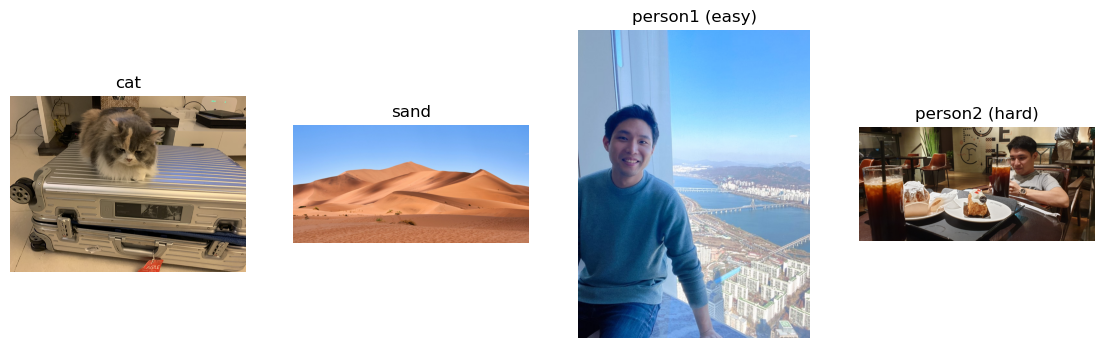

In [3]:
IMG_DIR = os.path.join(os.getcwd(), 'img')

cat_img     = cv2.cvtColor(cv2.imread(os.path.join(IMG_DIR, 'cat.png')),     cv2.COLOR_BGR2RGB)
sand_img    = cv2.cvtColor(cv2.imread(os.path.join(IMG_DIR, 'sand.png')),    cv2.COLOR_BGR2RGB)
person1_img = cv2.cvtColor(cv2.imread(os.path.join(IMG_DIR, 'person1.png')), cv2.COLOR_BGR2RGB)  # 잘 되는 케이스
person2_img = cv2.cvtColor(cv2.imread(os.path.join(IMG_DIR, 'person2.png')), cv2.COLOR_BGR2RGB)  # 안 되는 케이스

for name, im in [('고양이', cat_img), ('사막', sand_img), ('인물1', person1_img), ('인물2', person2_img)]:
    print(f'{name} : {im.shape}')

plt.figure(figsize=(14, 4))
plt.subplot(1, 4, 1); plt.imshow(cat_img);     plt.title('cat');             plt.axis('off')
plt.subplot(1, 4, 2); plt.imshow(sand_img);    plt.title('sand');            plt.axis('off')
plt.subplot(1, 4, 3); plt.imshow(person1_img); plt.title('person1 (easy)');  plt.axis('off')
plt.subplot(1, 4, 4); plt.imshow(person2_img); plt.title('person2 (hard)');  plt.axis('off')
plt.show()

## 3. 세그멘테이션으로 마스크 만들기

강의 순서 그대로다.

1. `Resize(520,520) → ToTensor` 로 모델 입력 만들기
2. `model(x)['out']` → 픽셀마다 클래스 점수 → `argmax` 로 클래스 라벨
3. 원본 크기로 다시 키우기
4. 피사체 클래스만 흰색(255)으로 남겨서 마스크 만들기

여러 사진에 쓸 거라 함수 하나로 묶었다.

In [4]:
# DeepLabV3 (처음엔 가중치 다운로드라 살짝 걸림)
model = deeplabv3_resnet101(pretrained=True).eval()

transform = T.Compose([
    T.ToPILImage(),
    T.Resize((520, 520)),
    T.ToTensor(),
])

# 마스크 클래스 ID가 뭔지 사람이 보려고 (PASCAL VOC)
VOC_CLASSES = ['background','aeroplane','bicycle','bird','boat','bottle','bus',
               'car','cat','chair','cow','diningtable','dog','horse','motorbike',
               'person','pottedplant','sheep','sofa','train','tvmonitor']
print('모델 준비 끝')

/opt/conda/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DeepLabV3_ResNet101_Weights.COCO_WITH_VOC_LABELS_V1`. You can also use `weights=DeepLabV3_ResNet101_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


모델 준비 끝


마스크를 원본 크기로 키울 때 그냥 `cv2.resize` 를 쓰면 클래스 라벨(8=cat, 0=배경)을 **숫자처럼 평균내서**
경계에 4 같은 엉뚱한 값이 섞인다. 라벨은 숫자가 아니라 종류니까 가장 가까운 값 그대로 복사하는
`INTER_NEAREST` 로 키웠다. (이거 안 했을 때 경계가 지저분해서 한참 헤맸다)

In [5]:
def get_mask(img_rgb, prefer=None):
    input_tensor = transform(img_rgb).unsqueeze(0)

    with torch.no_grad():
        output = model(input_tensor)['out'][0]                       # (21, 520, 520)
        output_predictions = output.argmax(0).byte().cpu().numpy()   # 픽셀마다 클래스 라벨

    # 라벨이라 NEAREST 로 키워야 경계에 엉뚱한 값이 안 섞임
    h, w = img_rgb.shape[:2]
    pred = cv2.resize(output_predictions, (w, h), interpolation=cv2.INTER_NEAREST)

    classes = np.unique(pred)
    print(f'예측된 클래스: {classes} ({[VOC_CLASSES[i] for i in classes]})')

    fg = classes[classes != 0]                                       # 배경(0) 제외
    if prefer is not None and prefer in fg:                          # 원하는 클래스가 잡혔으면 그걸로
        target = prefer
    else:                                                            # 아니면 픽셀 제일 많은 클래스
        target = max(fg, key=lambda c: int((pred == c).sum()))
    print(f'→ 피사체: {target} ({VOC_CLASSES[target]})')

    return (pred == target).astype(np.uint8) * 255   # 흰(255)=피사체, 검(0)=배경

고양이로 마스크를 뽑아본다. 고양이 모양대로 흰색이 떠야 한다.

예측된 클래스: [0 8] (['background', 'cat'])
→ 피사체: 8 (cat)


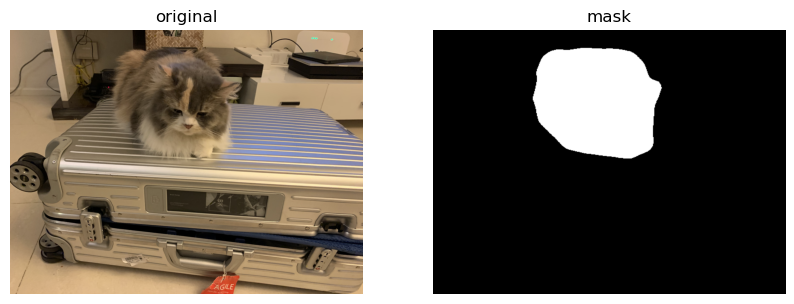

In [6]:
cat_mask = get_mask(cat_img)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1); plt.imshow(cat_img);              plt.title('original'); plt.axis('off')
plt.subplot(1, 2, 2); plt.imshow(cat_mask, cmap='gray'); plt.title('mask');    plt.axis('off')
plt.show()

마스크가 고양이 몸통(식빵 자세)을 거의 다 땄다. 다만 **푹신한 털 가장자리가 둥글게 깎여서** 살짝 뭉툭하다.
이게 나중에 합성에서 어떻게 보이는지 해보고 7번에서 분석하자.

## 4. 크로마키 (배경 교체) — 고양이를 사막에

마스크의 흰 부분(피사체)은 원본, 검은 부분(배경)은 새 배경으로 바꾸면 배경 교체가 된다.
강의의 `np.where` 합성을 그대로 썼다. 배경은 피사체 크기에 맞춰 resize.

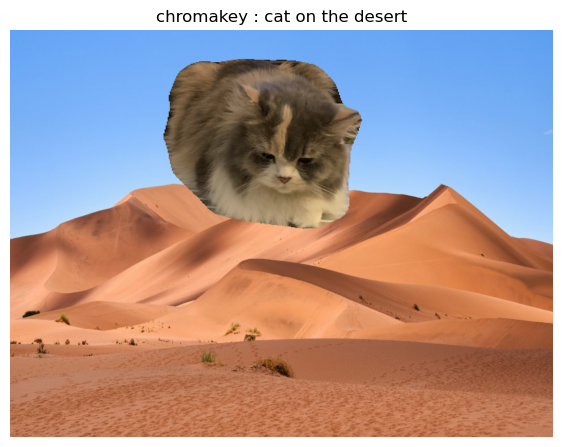

In [7]:
def chromakey(subject_rgb, mask, bg_rgb):
    h, w = subject_rgb.shape[:2]
    bg = cv2.resize(bg_rgb, (w, h))                       # 배경을 피사체 크기에 맞추기
    mask_3ch = cv2.cvtColor(mask, cv2.COLOR_GRAY2BGR)     # 3채널로 (안 그러면 np.where 모양 안 맞음)
    return np.where(mask_3ch == 255, subject_rgb, bg).astype(np.uint8)

cat_chroma = chromakey(cat_img, cat_mask, sand_img)

plt.figure(figsize=(7, 7))
plt.imshow(cat_chroma); plt.title('chromakey : cat on the desert'); plt.axis('off')
plt.show()

…고양이가 **사막 하늘에 둥둥 떠버렸다.** 합성은 됐는데 영 어색하다. 왜 이렇게 됐는지는 7번에서 따져본다.

## 5. 아웃포커싱 (배경 블러)

핸드폰 인물 모드는 배경을 바꾸는 게 아니라 **흐리게** 한다.
그래서 배경을 `GaussianBlur` 로 흐리게 만들고, 마스크로 **피사체만 선명하게** 남겼다.

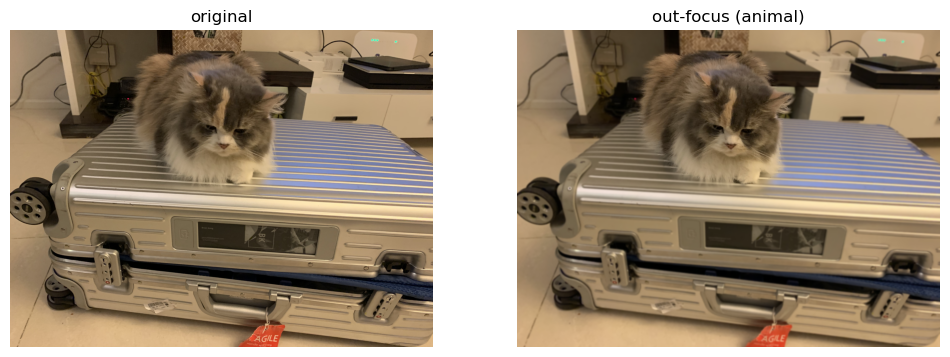

In [8]:
def out_focus(img_rgb, mask, ksize=35):
    if ksize % 2 == 0:                      # ksize 는 홀수여야 함
        ksize += 1
    blurred = cv2.GaussianBlur(img_rgb, (ksize, ksize), 0)
    mask_3ch = cv2.cvtColor(mask, cv2.COLOR_GRAY2BGR)
    return np.where(mask_3ch == 255, img_rgb, blurred).astype(np.uint8)   # 피사체=선명, 배경=블러

# 동물(고양이) 아웃포커싱
cat_focus = out_focus(cat_img, cat_mask, ksize=35)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1); plt.imshow(cat_img);   plt.title('original');            plt.axis('off')
plt.subplot(1, 2, 2); plt.imshow(cat_focus); plt.title('out-focus (animal)');  plt.axis('off')
plt.show()

아웃포커싱은 배경을 자리에 그대로 두고 흐리게만 하니까 크로마키보다 훨씬 자연스럽다.
그런데… **블러가 너무 약하다.** 캐리어가 거의 그대로 보인다. 색감이 비슷해서 그런가 싶었는데
아무래도 이상해서 좀 더 파봤다.

### 5-2. 블러가 약한 이유 → 사진 크기에 맞춰 키우기

찾아보니 색감 문제가 아니라 **블러 커널(ksize)이 사진에 비해 너무 작아서** 였다.
내 고양이 사진은 4032×3024짜리 초고해상도인데, `ksize=35` 는 폭 4032px 기준 **1%도 안 된다.**
블러 세기는 픽셀 절대값이라 사진이 크면 그만큼 약해진다. (핸드폰 화면 800px 였으면 35도 꽤 셌을 것)

거기에 배경이 **은색 캐리어**라 원래 매끈해서 뭉갤 디테일이 별로 없는 것도 한몫했다.
(보케는 배경에 잔디·점광원처럼 자잘한 게 많을 때 잘 산다)

그래서 ksize 를 고정값 말고 **사진 폭에 비례**하게 바꿨다.

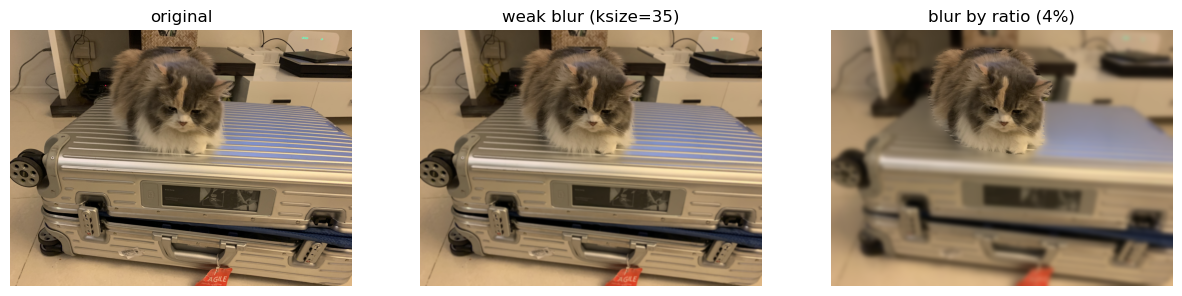

In [9]:
def out_focus_v2(img_rgb, mask, blur_ratio=0.04):
    # ksize 를 사진 폭에 비례시킴 → 큰 사진이든 작은 사진이든 비슷한 세기로 흐려짐
    h, w = img_rgb.shape[:2]
    ksize = int(w * blur_ratio)            # 폭의 4% (4032 → 약 161)
    if ksize % 2 == 0:                     # 홀수 보정
        ksize += 1
    blurred = cv2.GaussianBlur(img_rgb, (ksize, ksize), 0)
    mask_3ch = cv2.cvtColor(mask, cv2.COLOR_GRAY2BGR)
    return np.where(mask_3ch == 255, img_rgb, blurred).astype(np.uint8)

cat_focus_v2 = out_focus_v2(cat_img, cat_mask, blur_ratio=0.04)

# 약한 블러(ksize=35) vs 비례 블러 비교
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1); plt.imshow(cat_img);       plt.title('original');               plt.axis('off')
plt.subplot(1, 3, 2); plt.imshow(cat_focus);     plt.title('weak blur (ksize=35)');    plt.axis('off')
plt.subplot(1, 3, 3); plt.imshow(cat_focus_v2);  plt.title('blur by ratio (4%)');      plt.axis('off')
plt.show()

확실히 비례 블러 쪽이 캐리어가 제대로 날아가서 인물 모드 느낌이 산다.
`blur_ratio` 는 0.03~0.06 사이에서 조절하면 된다. 인물 사진에도 이 버전을 쓴다.

## 6. 인물 모드 (사람 아웃포커싱)

### 6-1. 잘 되는 케이스 (person1)
인물이 또렷하고 배경이랑 구분이 명확한 셀카는 사람(클래스 15)이 깔끔하게 떠진다.
블러는 위에서 만든 비례 버전(`out_focus_v2`)을 쓴다.

예측된 클래스: [ 0 15] (['background', 'person'])
→ 피사체: 15 (person)


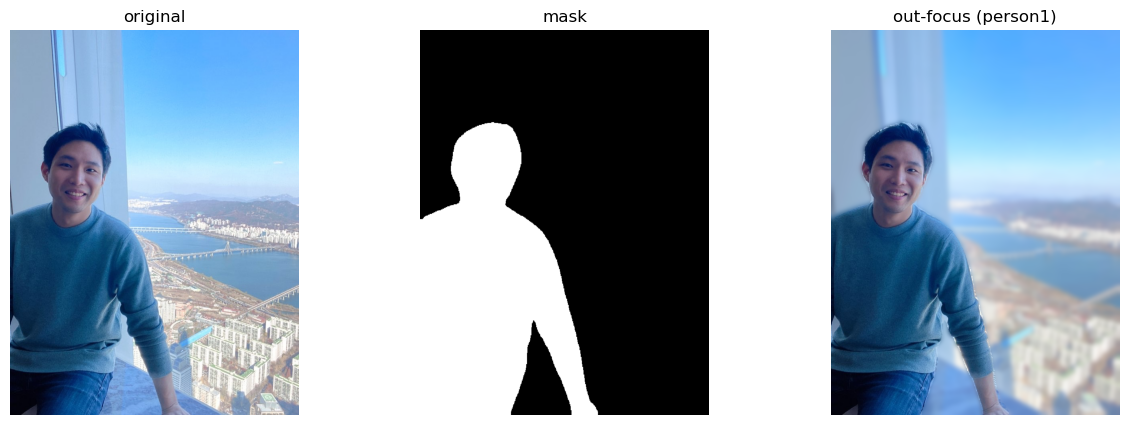

In [10]:
person1_mask  = get_mask(person1_img)
person1_focus = out_focus_v2(person1_img, person1_mask, blur_ratio=0.05)

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1); plt.imshow(person1_img);               plt.title('original');          plt.axis('off')
plt.subplot(1, 3, 2); plt.imshow(person1_mask, cmap='gray');  plt.title('mask');             plt.axis('off')
plt.subplot(1, 3, 3); plt.imshow(person1_focus);            plt.title('out-focus (person1)'); plt.axis('off')
plt.show()

인물이 가운데에 또렷하면 이렇게 잘 된다. 그럼 어려운 사진은 어떨까?

### 6-2. 안 되는 케이스 (person2) — 사람이 아니라 테이블이 떠버림
카페 사진(앞에 테이블·음료가 화면을 꽉 채우고, 인물은 오른쪽에 작게)으로 똑같이 돌려봤다.

예측된 클래스: [ 0  5  9 11 15] (['background', 'bottle', 'chair', 'diningtable', 'person'])
→ 피사체: 11 (diningtable)


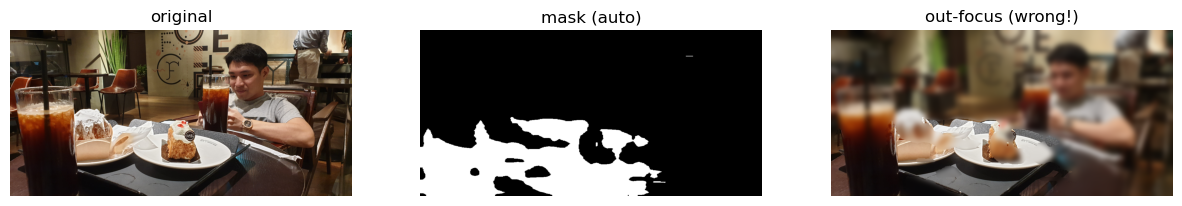

In [11]:
person2_mask  = get_mask(person2_img)                       # prefer 안 줌 = 자동선택
person2_focus = out_focus_v2(person2_img, person2_mask, blur_ratio=0.05)

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1); plt.imshow(person2_img);               plt.title('original');          plt.axis('off')
plt.subplot(1, 3, 2); plt.imshow(person2_mask, cmap='gray');  plt.title('mask (auto)');      plt.axis('off')
plt.subplot(1, 3, 3); plt.imshow(person2_focus);            plt.title('out-focus (wrong!)');  plt.axis('off')
plt.show()

사람을 흐리게 만들려던 건데 **엉뚱하게 테이블(diningtable)이 피사체로 떠버렸다.**

원인을 보면 DeepLab 이 사람을 못 잡은 게 아니다. (위 출력에 person 클래스도 같이 찍힌다)
문제는 내가 `get_mask` 에 넣은 자동선택 로직이다.

```python
target = max(fg, key=lambda c: int((pred == c).sum()))   # 픽셀 제일 많은 클래스
```

이 사진은 앞쪽 **테이블이 화면을 제일 많이 차지**하니까, 사람보다 테이블 픽셀이 많아서
"제일 큰 거 고르기" 가 테이블을 골라버린 거다. **모델이 아니라 내 후처리 로직이 틀린 선택**을 했다.

### 고치기 — 피사체를 자동 말고 '사람'으로 지정
아까 `get_mask` 에 `prefer` 를 넣어둔 게 이걸 위해서다. 사람 모드니까 `prefer=15`(person) 로 강제한다.

예측된 클래스: [ 0  5  9 11 15] (['background', 'bottle', 'chair', 'diningtable', 'person'])
→ 피사체: 15 (person)


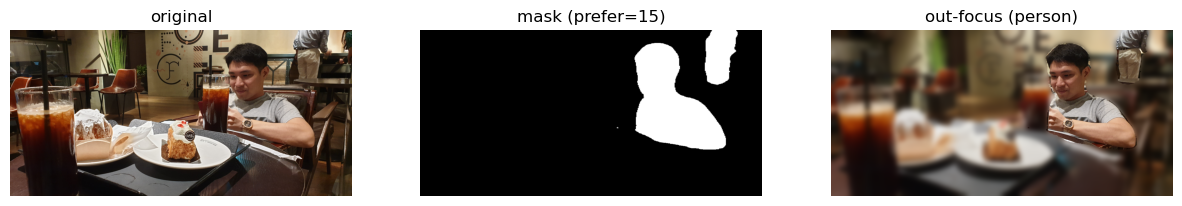

In [12]:
person2_mask2  = get_mask(person2_img, prefer=15)            # 사람(15)으로 지정
person2_focus2 = out_focus_v2(person2_img, person2_mask2, blur_ratio=0.05)

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1); plt.imshow(person2_img);                plt.title('original');           plt.axis('off')
plt.subplot(1, 3, 2); plt.imshow(person2_mask2, cmap='gray');  plt.title('mask (prefer=15)');  plt.axis('off')
plt.subplot(1, 3, 3); plt.imshow(person2_focus2);            plt.title('out-focus (person)');   plt.axis('off')
plt.show()

이제 사람이 피사체로 잡힌다. 그런데 `prefer=15` 로 사람을 강제로 떠도 **마스크가 깔끔하진 않다.**
- 들고 있는 **음료잔·팔**이 사람을 가려서(occlusion) 경계가 끊기거나 잔까지 먹는다
- **테이블에 가려진 하반신**은 아예 안 잡힌다
- 회색 티 ↔ 어두운 카페 배경처럼 **톤이 비슷한 데**서 샌다
- 게다가 **뒤에 서 있는 다른 사람**까지 같이 떠진다 — `prefer=15` 는 "person 픽셀 전부"를 고르니까
  화면에 사람이 둘이면 둘 다 잡힌다. 특정 한 명만 떼려면 *가장 큰 덩어리만 남기기* 같은 처리가 더 필요하다.

즉 자동선택만 고친다고 끝이 아니라, 이 사진 자체가 semantic seg 한테 어려운 케이스다.

## 7. 사진에서 뭐가 틀렸나 (문제점 찾기)

마스크 경계가 완벽하지 않아서 결과가 어색했다. 눈으로만 보면 놓치니까
**마스크 테두리를 원본 위에 빨갛게 그려서** 어디서 새는지 봤다.

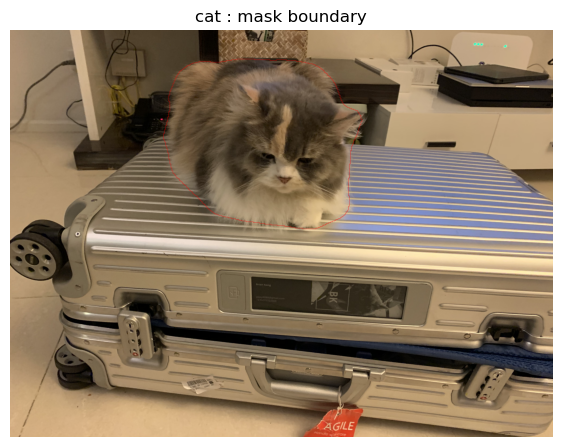

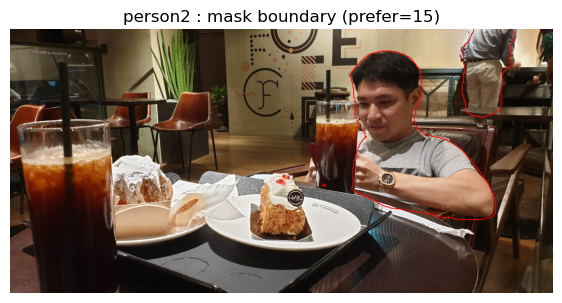

In [13]:
def show_mask_edge(img_rgb, mask, title):
    edge = cv2.Canny(mask, 50, 150)
    edge = cv2.dilate(edge, np.ones((2, 2), np.uint8))
    overlay = img_rgb.copy()
    overlay[edge > 0] = [255, 0, 0]                       # 경계 = 빨강
    plt.figure(figsize=(7, 7))
    plt.imshow(overlay); plt.title(title); plt.axis('off')
    plt.show()

show_mask_edge(cat_img,     cat_mask,      'cat : mask boundary')
show_mask_edge(person2_img, person2_mask2, 'person2 : mask boundary (prefer=15)')

### 떠 있는 고양이부터 — 왜 사막 하늘에 떴나

문제가 두 개인데 **성격이 완전히 다르다.** 헷갈리면 안 돼서 나눠서 봤다.

**(A) 합성 문제 — 하늘에 뜬 거 (이게 메인)**
`np.where` 는 피사체 픽셀을 **원래 있던 자리에 그대로** 둔다. 원본에서 고양이는 캐리어 위(화면 위쪽)에 있었고,
사막 배경은 위가 하늘이라 고양이가 **그 자리 그대로 하늘에 박혔다.** 게다가 합성에는 '땅'이나 '그림자' 개념이
없어서 더 둥 떠 보인다. 이건 **마스크가 100% 완벽해도 똑같이 뜬다** — 세그멘테이션이 아니라 합성 방식의 문제다.

**(B) 마스크 문제 — 털 가장자리가 매끈하게 깎임 (마이너)**
경계선을 보면 푹신한 털이 **둥근 블롭으로 뭉툭하게** 깎여있다. (다리가 잘린 건 아니다. 식빵 자세라 다리는
원래 안 보임) 520×520 으로 줄였다 키워서 fur 디테일이 날아갔고, semantic seg 는 픽셀을 '종류'로만 잡아서
부드러운 털 경계를 못 살린다. 캐리어가 은색이라 흰 털 밑단 경계도 살짝 애매하다.

### 정리한 문제점

고양이(크로마키)랑 인물(person2) 두 사진에서 나온 문제를 모았다.

| # | 문제 | 종류 | 원인 |
|---|---|---|---|
| 1 | 피사체가 엉뚱한 위치(하늘)에 떠 보임 | 합성 | 픽셀 위치를 그대로 유지 + 땅/그림자 개념 없음 |
| 2 | 털 가장자리가 뭉툭·톱니짐 (디테일 손실) | 마스크 | 520×520 축소→확대로 fur 경계 날아감 |
| 3 | **사람 대신 테이블이 피사체로 선택됨** | 후처리 로직 | 배경 물체가 더 크면 '픽셀 최다' 선택이 그걸 고름 → `prefer=15` 로 해결 |
| 4 | **가려진 부분(occlusion) 마스크 끊김·구멍** | 마스크 | 음료잔/팔이 사람을 가리고, 테이블에 하반신이 가려짐 |
| 5 | 톤 비슷한 곳 경계 샘 | 마스크 | 회색 티 ↔ 어두운 배경, 은색 캐리어 ↔ 흰 털 |
| 6 | 뒤에 서 있는 다른 사람까지 같이 떠짐 | 후처리 로직 | `prefer=15` 가 person 픽셀을 전부 고름 → 가장 큰 덩어리만 남기면 해결 |

3·6 번은 내 코드(휴리스틱) 쪽이고, 1·2·4·5 번은 semantic seg 자체의 한계라 다음 장(해결 방법)에서 다룬다.

## 8. 해결 방법 제안

7번에서 문제가 **합성(위치)** 과 **마스크(경계)** 두 종류로 나뉘었으니, 해결책도 나눠서 봤다.

### (A) 하늘에 뜨는 문제 → 합성 쪽을 손봐야 한다
이건 마스크를 아무리 잘 따도 안 고쳐진다. `np.where` 가 위치만 그대로 두기 때문.
- 피사체를 **배경의 지면 근처로 옮겨서** 붙이거나 (발이 지평선에 닿게)
- 밑에 **그림자**를 살짝 깔아서 땅에 붙은 느낌을 준다.
→ 즉 "어디에 놓을지(scene geometry)" 를 합성이 알아야 한다.

### (B) 털 경계가 뭉툭한 문제 → semantic 만으론 한계, 깊이 정보로 보완
여기서 semantic segmentation 의 본질적 한계가 나온다.
아웃포커싱(피사계 심도)은 원래 렌즈가 **거리(깊이)** 로 구별하는 건데, semantic seg 는 거리를 못 보고
**"이 픽셀이 무슨 종류냐"** 만 본다. 그래서 정확도가 1.00 이 아니고, 푹신한 털처럼 종류가 애매한 경계를
딱 못 자른다.

보완책으로 **종류(semantic) + 거리(depth)** 를 같이 쓰는 걸 골랐다.
1. semantic seg 로 대략 피사체를 잡고 (지금까지 한 것)
2. **깊이 맵**으로 "가깝다/멀다" 를 구해서, 은색 캐리어처럼 색이 비슷해 애매하던 경계도 거리로 갈라주고
3. 경계만 **알파 매팅**으로 부드럽게 다듬어 털 디테일을 살린다

**깊이 맵 얻는 법** (강의 참고자료)
- 하드웨어: ToF 센서 / 스테레오(듀얼) 카메라 / IR 깊이 센서 → 거리를 직접 측정
- 소프트웨어: 단일 카메라에서 딥러닝으로 깊이 추정 (struct2depth, uDepth 등)

정리하면, **뜨는 문제는 합성을 고쳐서, 경계 문제는 깊이 정보로** 보완하는 게 내 결론이다.

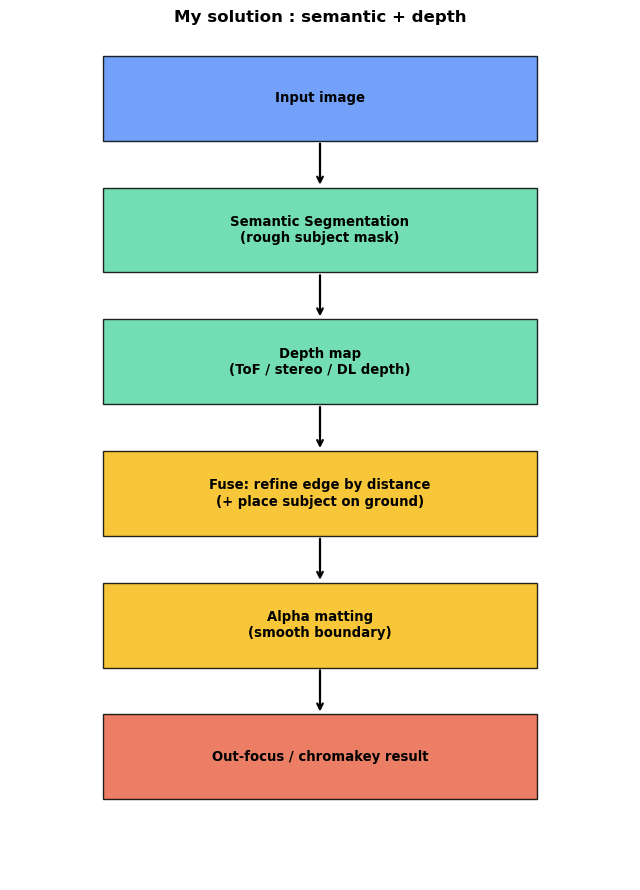

In [14]:
# 내가 제안하는 파이프라인 순서도
fig, ax = plt.subplots(figsize=(6.5, 9))
ax.axis('off')

steps = [
    ('Input image', '#5B8FF9'),
    ('Semantic Segmentation\n(rough subject mask)', '#5AD8A6'),
    ('Depth map\n(ToF / stereo / DL depth)', '#5AD8A6'),
    ('Fuse: refine edge by distance\n(+ place subject on ground)', '#F6BD16'),
    ('Alpha matting\n(smooth boundary)', '#F6BD16'),
    ('Out-focus / chromakey result', '#E8684A'),
]
y, dy, bw, bh = 0.92, 0.155, 0.7, 0.10
ys = []
for text, color in steps:
    ax.add_patch(plt.Rectangle((0.5 - bw/2, y - bh/2), bw, bh,
                               facecolor=color, edgecolor='black', alpha=0.85))
    ax.text(0.5, y, text, ha='center', va='center', fontsize=9.5, weight='bold')
    ys.append(y); y -= dy
for i in range(len(ys) - 1):
    ax.annotate('', xy=(0.5, ys[i+1] + bh/2), xytext=(0.5, ys[i] - bh/2),
                arrowprops=dict(arrowstyle='->', lw=1.6))
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_title('My solution : semantic + depth', fontsize=12, weight='bold')
plt.tight_layout(); plt.show()

## 9. 회고

제일 헷갈렸던 게, 고양이가 사막 하늘에 둥둥 떠버린 걸 보고 처음엔 "마스크가 고양이 다리를 잘랐나?" 했는데
다시 보니 그게 아니었다. 식빵 자세라 다리는 원래 안 보였고, 마스크도 몸통은 거의 다 땄다.
진짜 원인은 **`np.where` 가 픽셀 위치를 그대로 둬서** 캐리어 위(화면 위쪽)에 있던 고양이가 하늘에 박힌 거였다.
즉 **세그멘테이션 문제가 아니라 합성 문제**였다. 문제를 잘못 짚을 뻔했는데, 경계선을 직접 그려보고 나서야
"위치 문제(합성)" 랑 "경계 문제(마스크)" 가 따로라는 걸 갈라낼 수 있었다.

기술적으로는 두 가지를 배웠다. 하나는 마스크를 키울 때 `INTER_NEAREST` 를 써야 라벨이 안 섞인다는 것.
처음엔 경계가 지저분해서 모델 탓인 줄 알았는데 내가 라벨을 평균내고 있던 거였다.
다른 하나는 블러 세기(ksize)가 **픽셀 절대값**이라 큰 사진에선 약해진다는 것. 사진 폭에 비례시키니까 해결됐다.
(아웃포커싱이 약했던 게 색감 탓인 줄 알았는데 사실 커널 크기 문제였다)

아쉬운 건 푹신한 털 경계다. 마스크가 픽셀 단위라 한 올 한 올은 못 살린다.
다음엔 알파 매팅을 붙여서 경계를 더 부드럽게, 합성도 지면에 맞춰 놓아보고 싶다.

인물 사진에서도 하나 배웠다. 카페 사진을 넣었더니 사람이 아니라 앞 테이블이 떠버렸는데,
모델이 틀린 게 아니라 내가 짠 '픽셀 제일 많은 클래스 고르기' 가 큰 배경 물체를 골라버린 거였다.
`prefer=15` 로 사람을 지정하니까 해결됐다. 잘 되는 사진(person1)이랑 안 되는 사진(person2)을 같이 보니까
**언제 잘 되고 언제 터지는지**(인물이 작거나, 앞에 큰 물체가 있거나, 가려지면 약함) 가 확실히 보였다.